In [5]:
import numpy as np
import matplotlib.pyplot as plt
from core.file_manager import preprocess_file_manager
from core.visualization_lib import normalize_volume
from core.helper import  sikit_to_just_data
from core.visualization_lib import show_transformation

In [6]:
orginal_data_folder =  '/home/robakp/Exeriments1/prostate_lesion_detection/rjozwiak-MGR_dataset_correct/MGR_dataset_correct'

channels = {
    'adc' : 'adc',
    'anatomy' : 'anatomy',
    'dwi' : 'dwi',
    't2' : 't2'
}

target = 'lesion'

file_extention = '.nii.gz'

preprocessed_steps = [
    'raw',
    'filling_anatomy_gaps'
]

crop_size = (160,160,24)

In [7]:
file_manager = preprocess_file_manager('/home/robakp/Exeriments1/prostate_lesion_detection/juzwiak_preprocessed',preprocessed_steps,channels)
patients = file_manager.get_file_names()

In [8]:
from core.cropping_lib import center_crop_shift
from core.stat_calc import find_centroid_non_weighted

for patient in patients:
    data = file_manager.load_file('raw', patient)
    center = find_centroid_non_weighted(data['anatomy'])
    shifted_data = center_crop_shift(data['anatomy'],center,crop_size)

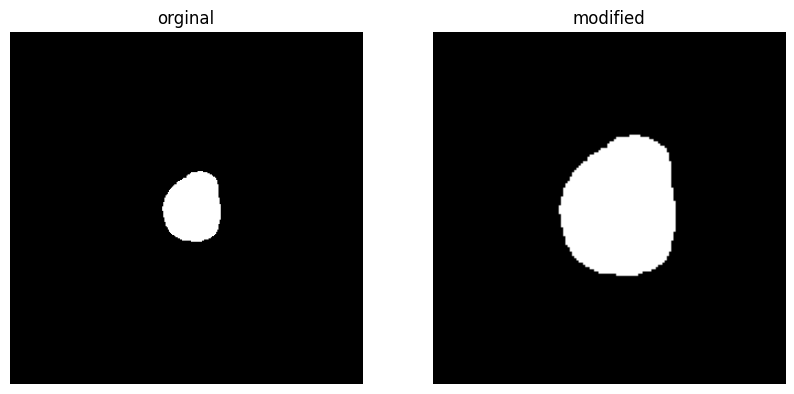

In [9]:
data_to_show = {
    'orginal' : normalize_volume(sikit_to_just_data(file_manager.load_file_NiFty_external(orginal_data_folder,patients[-1],channels))['anatomy'][:, :, 19]),
    'modified' : shifted_data[:,:,9],
}
show_transformation(data_to_show)